In [70]:
from google.cloud import bigquery

import numpy as np

import matplotlib.pyplot as plt
import igraph as ig
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import csv
from math import floor
import json

In [2]:
client = bigquery.Client(project='gcp-cset-projects')

In [4]:
cluster_size_query = """
SELECT
  cluster_id,
  COUNT(family_id) AS size
FROM staging_patent_clusters.cluster_assignment
GROUP BY cluster_id
ORDER BY cluster_id
"""
result = client.query(cluster_size_query)
cluster_sizes = []
for row in result:
    temp_dict = {'cluster_id':row['cluster_id'],'size':row['size']}
    cluster_sizes.append(temp_dict)

max_size = max([r['size'] for r in cluster_sizes])
max_cluster_id = max([r['cluster_id'] for r in cluster_sizes])
vertex_sizes = [0 for i in range(max_cluster_id+1)]
for row in cluster_sizes:
    vertex_sizes[row['cluster_id']] = np.sqrt(row['size']/max_size)
vertex_sizes = np.array(vertex_sizes)

In [40]:
cluster_category_query = """
WITH
family_categories AS (
  SELECT
    DISTINCT
    family_id,
    cluster_id,
    CASE
        WHEN technology_category = 'manufacturing' AND category IN ('metals_manufacturing','textile_manufacturing','apparel_manufacturing') THEN category
        WHEN technology_category IN ('computing_and_peripherals','telecommunications') THEN 'computing_and_telecommunications'
        WHEN technology_category IN ('optics_and_photography','semiconductors_and_electronics') THEN 'optics_photography_semiconductors_electronics'
        WHEN technology_category IN ('construction','mining_and_quarrying') THEN 'construction_and_mining'
        WHEN technology_category IN ('food_and_tobacco','agriculture') THEN 'food_and_agriculture'
        WHEN technology_category IN ('biotechnology','pharmaceuticals') THEN 'biotechnology_and_pharmaceutical'
        WHEN technology_category = 'waste_management_and_remediation' OR category='electricity_gas_steam_ac_supply' THEN 'energy_and_waste_management'
        WHEN technology_category = 'energy_management' AND category='electrical_equipment_manufacturing' THEN category
        ELSE technology_category END AS category
  FROM staging_patent_clusters.cluster_assignment
  LEFT JOIN patent_categories.categories USING(family_id)
  WHERE cluster_id IS NOT NULL
),
cluster_categories AS (
  SELECT
    DISTINCT
    cluster_id,
    category,
    COUNT(*) AS n_patents
  FROM family_categories
  WHERE category IS NOT NULL
  GROUP BY cluster_id, category
),
cluster_categories_ranking AS (
  SELECT
    DISTINCT
    cluster_id,
    category,
    n_patents,
    ROW_NUMBER() OVER (PARTITION BY cluster_id ORDER BY n_patents DESC) AS cat_rank
  FROM cluster_categories
),
cluster_sizes AS (
    SELECT
      cluster_id,
      COUNT(family_id) AS size
    FROM staging_patent_clusters.cluster_assignment
    GROUP BY cluster_id
    ORDER BY cluster_id
)

SELECT
  cluster_id,
  category,
  x,
  y,
  size
FROM cluster_categories_ranking
LEFT JOIN patent_clusters.cluster_locations USING(cluster_id)
LEFT JOIN cluster_sizes USING(cluster_id)
WHERE cat_rank = 1
ORDER BY cluster_id
"""

result = client.query(cluster_category_query)
cluster_metadata = []
for row in result:
    temp_dict = {k:row[k] for k in row.keys()}
    cluster_metadata.append(temp_dict)

In [20]:
manual_colors = [
    '#0B1F41',
    '#003DA6',
    '#7C336F',
    '#B53A6D',
    '#3C8786',
    '#7AC4A5',
    '#F17F4C',
    '#15AFD0',
    '#839DC5',
    '#E5BF21',
    '#B42025',
    '#EF384D',
    '#D4FAFA',
    '#63676B',
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:olive',
    'tab:cyan',
    'orchid',
    'olive'
]

In [47]:
category_query = """
SELECT
  DISTINCT
    CASE
        WHEN technology_category = 'manufacturing' AND category IN ('metals_manufacturing','textile_manufacturing','apparel_manufacturing') THEN category
        WHEN technology_category IN ('computing_and_peripherals','telecommunications') THEN 'computing_and_telecommunications'
        WHEN technology_category IN ('optics_and_photography','semiconductors_and_electronics') THEN 'optics_photography_semiconductors_electronics'
        WHEN technology_category IN ('construction','mining_and_quarrying') THEN 'construction_and_mining'
        WHEN technology_category IN ('food_and_tobacco','agriculture') THEN 'food_and_agriculture'
        WHEN technology_category IN ('biotechnology','pharmaceuticals') THEN 'biotechnology_and_pharmaceutical'
        WHEN technology_category = 'waste_management_and_remediation' OR category='electricity_gas_steam_ac_supply' THEN 'energy_and_waste_management'
        WHEN technology_category = 'energy_management' AND category='electrical_equipment_manufacturing' THEN category
        ELSE technology_category END AS category
FROM patent_categories.categories
ORDER BY category
"""

result = client.query(category_query)
categories = {}
i = 0
for row in result:
    categories[row['category']] = manual_colors[i]
    i += 1

In [48]:
cluster_colors = [categories[r['category']] for r in cluster_metadata]

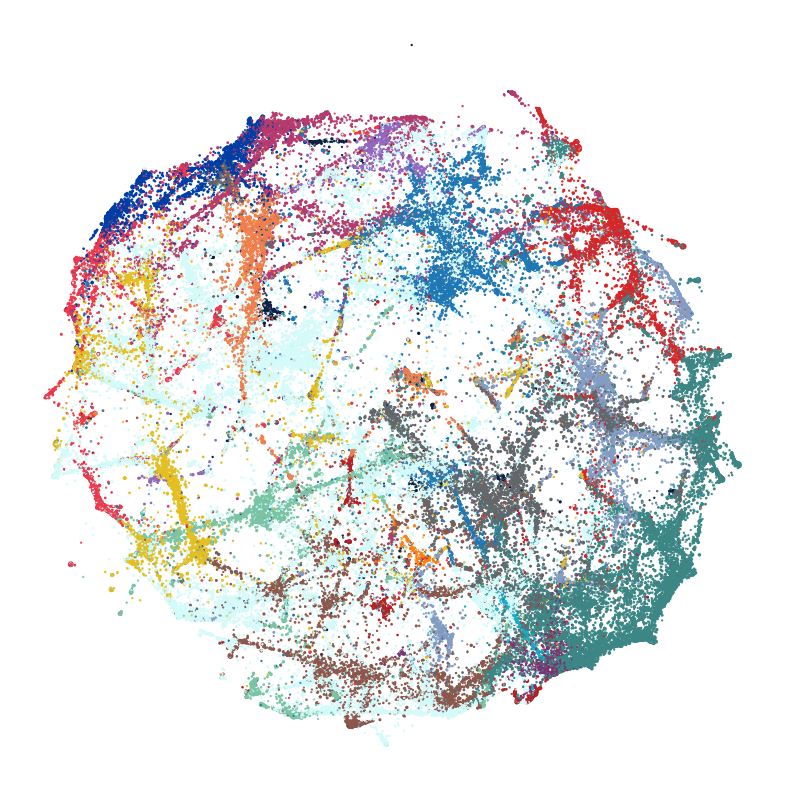

In [50]:
x = [r['x'] for r in cluster_metadata]
y = [r['y'] for r in cluster_metadata]
max_size = 20
vertex_sizes = np.array([r['size'] for r in cluster_metadata])
size_norm = max(vertex_sizes)
vertex_sizes = vertex_sizes * max_size / size_norm

plt.figure(figsize=(10,10))

plt.scatter(x,y, s = vertex_sizes, c=cluster_colors)
plt.gca().set_aspect('equal')
plt.gca().axis('off')
#plt.title('Patent Clusters', fontsize=100)
plt.savefig('cluster_visual.png',bbox_inches='tight', transparent=True)
plt.show()

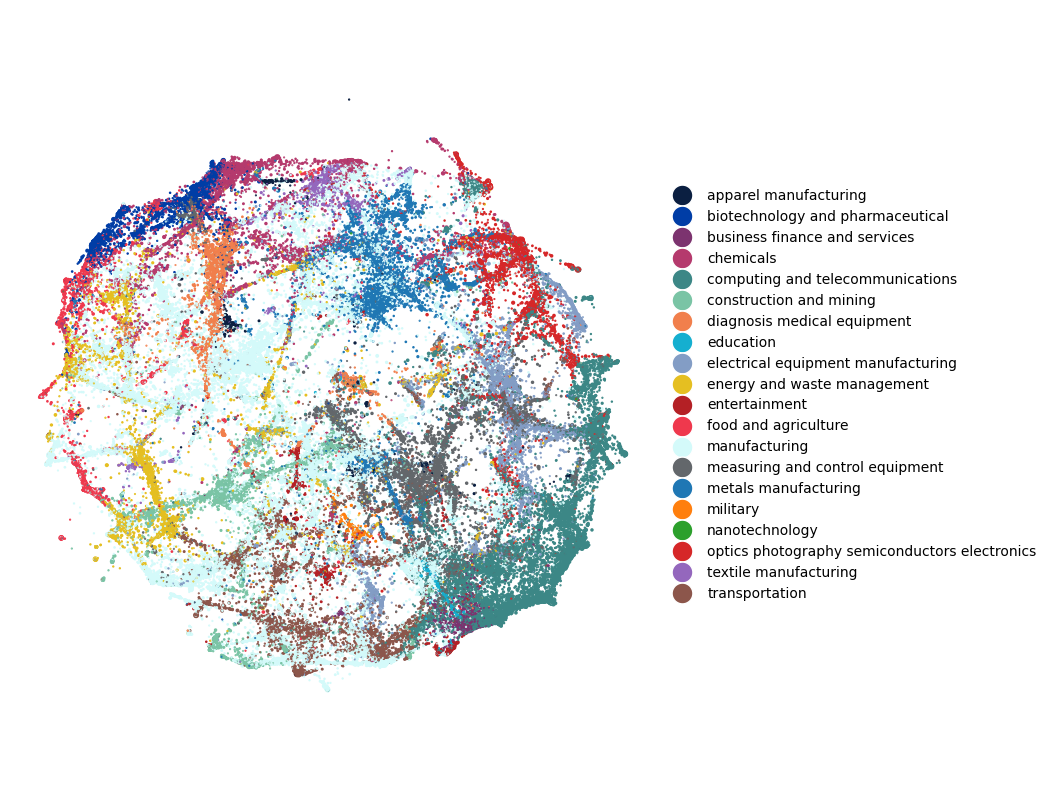

In [73]:
fig, axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [5, 1]},figsize=(10,10))

x = [r['x'] for r in cluster_metadata]
y = [r['y'] for r in cluster_metadata]
max_size = 20
vertex_sizes = np.array([r['size'] for r in cluster_metadata])
size_norm = max(vertex_sizes)
vertex_sizes = vertex_sizes * max_size / size_norm

axs[0].scatter(x,y, s = vertex_sizes, c=cluster_colors)
axs[0].set_aspect('equal')
axs[0].axis('off')

field_legends = []
for name in names:
    c=categories[name]
    name = name.replace("_"," ")
    field_legends.append(Line2D([0],[0], marker='o', color='white', label=name, markerfacecolor=c, markersize=15))

axs[1].legend(handles=field_legends, loc='center left', frameon=False, fontsize=10)
axs[1].axis('off')
    
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [66]:
mpatches.Patch?